In [1]:
from scipy.special import erf
import os, xarray as xr
import numpy as np
import pandas as pd
from pathlib import Path
import re
import bisect
import glob
import sys
import matplotlib.pyplot as plt
from metpy.plots import SkewT
from metpy.units import units
from dask_jobqueue import PBSCluster
from dask.distributed import Client
import dask
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
xr.set_options(file_cache_maxsize=1)       # do NOT set 0 on your xarray version
# from dask import compute as dask_compute
import inform_utils as inform
import cam_era5_functions as cfun
import cam_diagnostic as cdog
# Add parent directory to sys.path
parent_dir = Path('/glade/u/home/patnaude/inform/').resolve().parent.parent
sys.path.append(str(parent_dir))
import dask.array as da
import matplotlib.ticker as mticker
from scipy import stats

# Start dask cluster for quicker computing
* ### usually needed for running these cells

In [2]:
cluster = PBSCluster(
    cores = 1,
    memory = '30GB',
    processes = 1,
    queue = 'casper',
    local_directory = '$TMPDIR',
    resource_spec = 'select=1:ncpus=1:mem=30GB',
    account='P04010022',
    walltime='03:00:00',
    interface='mgt')

# scale up
cluster.scale(24)

# change your urls to the dask dashboard so that you can see it
dask.config.set({'distributed.dashboard.link':'https://jupyterhub.hpc.ucar.edu/stable/user/{USER}/proxy/{port}/status'})

# Setup your client
client = Client(cluster)


In [3]:
cluster

Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/patnaude/proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://10.18.206.10:39705,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/patnaude/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [5]:
# Located folder with .nc CAM output
cam_dir = Path("/glade/derecho/scratch/islas/archive/f.e30_cam6_4_120.FHIST_BGC.f09_f09_mg17.SOCRATES_nudgeUVTfull_withCOSP_tau6h.002/atm/hist")
# Select campaign
campaign = 'SOCRATES'

if campaign == 'SOCRATES':
    lat_slice = slice(-62, -42)
    lon_slice = slice(135, 165)   # 0..360 convention
elif campaign == 'CSET':
    lat_slice = slice(15, 45)
    lon_slice = slice(200, 240)

file_sel = "cam.h0"

ds_sonde = xr.open_dataset(f'/glade/u/home/patnaude/inform/{campaign}_sonde_data_composite.nc')
df_sonde = ds_sonde.to_dataframe()
# df_sonde[df_sonde.RF==rf_num]

# Will use aircraft flight times to extract model data
file_paths = sorted(glob.glob(f'/glade/u/home/patnaude/inform/composited data/*{campaign}*.nc'))
comp_air_dat = inform.load_nc_cldrgme(file_paths)
# time = comp_air_dat[comp_air_dat.flight=='RF01'].Time
time = comp_air_dat.Time

# Your time series (pandas Series or DataFrame column)
# e.g., df['Time'] or a Series named "Time"
time_ser = time.astype('datetime64[ns]')
tmin = pd.to_datetime(time_ser.min()).to_pydatetime()
tmax = pd.to_datetime(time_ser.max()).to_pydatetime()


## Load CAM and ERA5 datasets

In [7]:
ds_era5 = cfun.load_era5_files(tmin, tmax, lat_slice, lon_slice)
ds_cam = cfun.load_cam_files(cam_dir, file_sel, tmin, tmax, campaign=campaign)

# Create datasets for CAM state, microphysics and aerosol concentrations based on aircraft instrumentation
ds_out = cfun.compute_cam_aerosol_micphys_metrics(ds_cam, lat_slice=lat_slice, lon_slice=lon_slice) # dataset with all the microphysics, state, and aerosol parameters

Selected 41 ERA5-PL files (t) from
  e5.oper.an.pl.128_130_t.ll025sc.2018011500_2018011523.nc
to
  e5.oper.an.pl.128_130_t.ll025sc.2018022400_2018022423.nc
Selected 41 ERA5-PL files (u) from
  e5.oper.an.pl.128_131_u.ll025uv.2018011500_2018011523.nc
to
  e5.oper.an.pl.128_131_u.ll025uv.2018022400_2018022423.nc
Selected 41 ERA5-PL files (v) from
  e5.oper.an.pl.128_132_v.ll025uv.2018011500_2018011523.nc
to
  e5.oper.an.pl.128_132_v.ll025uv.2018022400_2018022423.nc
Selected 41 ERA5-PL files (q) from
  e5.oper.an.pl.128_133_q.ll025sc.2018011500_2018011523.nc
to
  e5.oper.an.pl.128_133_q.ll025sc.2018022400_2018022423.nc
Selected 192 CAM files from f.e30_cam6_4_120.FHIST_BGC.f09_f09_mg17.SOCRATES_nudgeUVTfull_withCOSP_tau6h.002.cam.h0i.2018-01-15-70200.nc to f.e30_cam6_4_120.FHIST_BGC.f09_f09_mg17.SOCRATES_nudgeUVTfull_withCOSP_tau6h.002.cam.h0i.2018-02-24-52200.nc
loaded CAM ds


## Composite CAM data

In [8]:
# # Create dataset of CAM cloud controlling factors for compositing of CAM data similar to sonde/aircraft observations
ds_cam_ccfs = cfun.load_cam_ccfs(ds_cam, lat_slice=lat_slice, lon_slice=lon_slice) # dataset used for compositing above dataset
print('loaded ccfs')
# # Composite the CAM data using thresholds defined by aircraft observations.
# ## Use Cluster running this for CAM7
ds_cam_comp = cfun.subset_cam_by_campaign(ds_out,ds_cam_ccfs,campaign=campaign)
print('composited')

loaded ccfs


/glade/work/patnaude/inform/inform_env/lib/python3.10/site-packages/distributed/client.py:3374: UserWarning: Sending large graph of size 17.16 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


composited


# Plot Diagnostics

# 1. Dropsonde comparison

/glade/work/patnaude/inform/inform_env/lib/python3.10/site-packages/distributed/client.py:3374: UserWarning: Sending large graph of size 2.56 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


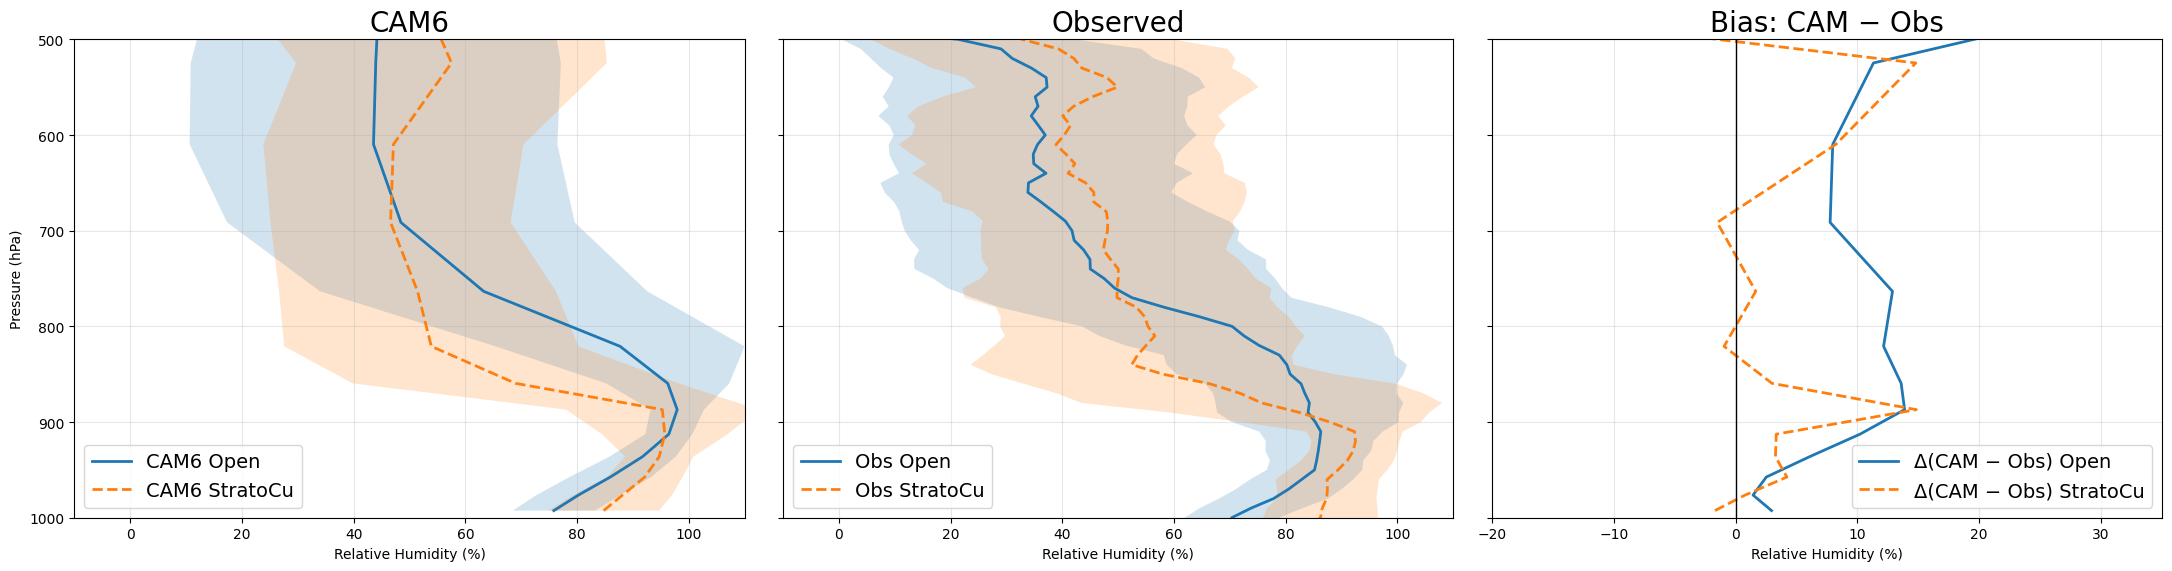

In [11]:
# =============================================================================
# 6. EXAMPLE USAGE (ADJUST VARIABLE NAMES IF NEEDED)
# =============================================================================

sonde_var = "rh" # tdry, u_wind, v_wind, rh
cam_var = "RH" # T_K, RH, U, V
era_var = "RH" # T_K, RH, U, V

# Assumes you already ran something like:
ds_sonde = xr.open_dataset(f'/glade/u/home/patnaude/inform/{campaign}_sonde_data_composite.nc')
df_sonde = ds_sonde.to_dataframe()
df_sonde["tdry"] = df_sonde["tdry"] + 273.15
df_sonde["dp"]   = df_sonde["dp"]   + 273.15


# start from your open_mfdataset outputs
ds_cam_sub = ds_out[[cam_var]].chunk({"time": -1, "lev": -1}).persist()
ds_era = ds_era5[[era_var]].chunk({"time": -1, "level": -1}).persist()

### --- Open-Cell regime ---
df_open, p_cam_open_raw, cam_arr_open, p_era_open_raw, era_arr_open = cdog.collocate_model_profiles_for_regime(
    df_sonde,
    ds_cam_sub, # CAM
    ds_era,     # ERA5
    regime_name="Open-Cell",
    sonde_var=sonde_var,
    cam_var=cam_var,
    era_var=era_var,
    cam_lat_name="lat",
    cam_lon_name="lon",
    cam_lev_name="lev",
    era_lat_name="latitude",
    era_lon_name="longitude",
    era_lev_name="level",
    to_percent_models=True,
)

prof_sonde_open = cdog.sonde_profile(df_open, sonde_var, bin_hPa=10, to_percent=True)

p_cam_open, cam_open_mean, cam_open_std = cdog.mean_std_from_profiles(
    p_cam_open_raw, cam_arr_open
)
p_era_open, era_open_mean, era_open_std = cdog.mean_std_from_profiles(
    p_era_open_raw, era_arr_open
)

### --- Stratocumulus regime ---
df_strat, p_cam_strat_raw, cam_arr_strat, p_era_strat_raw, era_arr_strat = cdog.collocate_model_profiles_for_regime(
    df_sonde,
    ds_cam_sub,
    ds_era,
    regime_name="Stratocumulus",
    sonde_var=sonde_var,
    cam_var=cam_var,
    era_var=era_var,
    cam_lat_name="lat",
    cam_lon_name="lon",
    cam_lev_name="lev",
    era_lat_name="latitude",
    era_lon_name="longitude",
    era_lev_name="level",
    to_percent_models=True,
)

prof_sonde_strat = cdog.sonde_profile(df_strat, sonde_var, bin_hPa=10, to_percent=True)

p_cam_strat, cam_strat_mean, cam_strat_std = cdog.mean_std_from_profiles(
    p_cam_strat_raw, cam_arr_strat
)
p_era_strat, era_strat_mean, era_strat_std = cdog.mean_std_from_profiles(
    p_era_strat_raw, era_arr_strat
)

# Separate dropsondes based on cloud regime
# --- Counts of physical drops (RF, drop_num) in each regime ---
N_open  = df_open.groupby(["RF", "drop_num"]).ngroups
N_strat = df_strat.groupby(["RF", "drop_num"]).ngroups

# COMMENT

#========================================= 
# Figure 1. 3 panels with CAM, ERA5, Obs
#=========================================
#
# fig = cdog.plot_three_panels_profiles_with_era(
#     prof_sonde_open, prof_sonde_strat,
#     p_cam_open,  cam_open_mean,  cam_open_std,
#     p_cam_strat, cam_strat_mean, cam_strat_std,
#     p_era_open,  era_open_mean,  era_open_std,
#     p_era_strat, era_strat_mean, era_strat_std,
#     N_open, N_strat,
#     var_label="Relative Humidity (%)",
#     ylim_hPa=(1000, 500), xlim_hPa=(-10,110),xlim_delta=(-35,20)
# )
# plt.savefig('SOCRATES_RHvprof_diff_coll_cam_era5_CAM6_6hrnudgUTV.png',dpi=300,bbox_inches='tight')

#======================================================================== 
# Figure 2. 3 panels with CAM and Obs, difference between cloud regimes
#========================================================================

fig = cdog.plot_three_panels_cam_obs_delta_cam_minus_obs(
    prof_sonde_open, prof_sonde_strat,
    p_cam_open,  cam_open_mean,  cam_open_std,
    p_cam_strat, cam_strat_mean, cam_strat_std,
    N_open, N_strat,
    var_label="Relative Humidity (%)",
    ylim_hPa=(1000, 500), xlim_hPa=(-10,110),xlim_delta=(-20,35),
    cam_label="CAM6"
)
# plt.savefig('SOCRATES_RHvprof_diff_coll_cam_CAM6_6hrnudgUTV_v2.png',dpi=300,bbox_inches='tight')

## 2. Microphysical Properties Comparison - cloud regimes

In [15]:
file_paths = sorted(glob.glob("/glade/u/home/patnaude/inform/composited data/*SOCRATES*.nc"))
All_rf_df = inform.load_nc_cldrgme(file_paths)

fig, axes, pdfs = cdog.plot_obs_cam_nd_lwc_pdfs(
    All_rf_df=All_rf_df,
    ds_cam_comp=ds_cam_comp,
    savepath=None,
)

def plot_obs_cam_nd_lwc_pdfs(
    All_rf_df,
    ds_cam_comp,
    labels_of_interest=("In-Cloud Level FT", "In-Cloud Profiles"),
    regimes_of_interest=("Stratocumulus", "Open-Cell"),
    cam_regime_keys=None,
    Nd_bins=None,
    LWC_bins=None,
    obs_Nd_min=10.0,
    obs_LWC_min=0.001,
    cam_Nd_min=10.0,
    cam_LWC_min=0.001,
    T_min_C=0.0,
    figsize=(12, 5),
    savepath=None,
    show=True,
):
    """
    Plot normalized 1D PDFs of Nd and LWC for observations and CAM6 by cloud regime.

    Assumes:
      Obs dataframe has:
        - block_label
        - cloud_regime
        - ATX in deg C
        - CONCD* column for Nd
        - PLWCD* or PLWC column for LWC

      CAM datasets have:
        - T_K in K
        - cam_Nc in cm^-3
        - cam_lwc in g m^-3
    """

    import numpy as np
    import matplotlib.pyplot as plt
    import dask.array as da

    if Nd_bins is None:
        Nd_bins = np.logspace(-1, 3, 15)

    if LWC_bins is None:
        LWC_bins = np.logspace(-3, 1, 15)

    Nd_centers = np.sqrt(Nd_bins[:-1] * Nd_bins[1:])
    LWC_centers = np.sqrt(LWC_bins[:-1] * LWC_bins[1:])

    if cam_regime_keys is None:
        cam_regime_keys = {
            "Stratocumulus": "strat",
            "Open-Cell": "open",
        }

    cam_ds = {
        regime: ds_cam_comp[cam_regime_keys[regime]]
        for regime in regimes_of_interest
    }

    def _find_obs_columns(df):
        concd_col = next((c for c in df.columns if "CONCD" in c), None)
        if concd_col is None:
            raise ValueError("Could not find a 'CONCD*' column in obs dataframe.")

        plwc_col = next((c for c in df.columns if "PLWCD" in c), None)
        if plwc_col is None:
            plwc_col = next((c for c in df.columns if c == "PLWC" or "PLWC" in c), None)
        if plwc_col is None:
            raise ValueError("Could not find a PLWC/PLWCD column in obs dataframe.")

        return concd_col, plwc_col

    def compute_pdf_1d(vals, bins):
        vals = np.asarray(vals)
        vals = vals[np.isfinite(vals)]

        if vals.size == 0:
            return np.zeros(len(bins) - 1, dtype=float)

        counts, _ = np.histogram(vals, bins=bins)

        if counts.sum() == 0:
            return np.zeros_like(counts, dtype=float)

        return counts.astype(float) / counts.sum()

    def compute_pdf_dask(da_vals, bins):
        arr = da_vals.data
        arr = arr[da.isfinite(arr)]

        hist, _ = da.histogram(arr, bins=bins)
        hist = hist.compute().astype(float)

        if hist.sum() == 0:
            return np.zeros_like(hist, dtype=float)

        return hist / hist.sum()

    concd_col_obs, plwc_col_obs = _find_obs_columns(All_rf_df)

    pdf_Nd_obs = {}
    pdf_LWC_obs = {}
    pdf_Nd_cam = {}
    pdf_LWC_cam = {}

    for regime in regimes_of_interest:

        # --------------------------
        # Observations
        # --------------------------
        df_sub = All_rf_df[
            (All_rf_df["block_label"].isin(labels_of_interest)) &
            (All_rf_df["cloud_regime"] == regime) &
            (All_rf_df[concd_col_obs] > obs_Nd_min) &
            (All_rf_df[plwc_col_obs] > obs_LWC_min) &
            (All_rf_df["ATX"] > T_min_C)
        ]

        pdf_Nd_obs[regime] = compute_pdf_1d(df_sub[concd_col_obs].values, Nd_bins)
        pdf_LWC_obs[regime] = compute_pdf_1d(df_sub[plwc_col_obs].values, LWC_bins)

        # --------------------------
        # CAM6
        # --------------------------
        ds_reg = cam_ds[regime]

        T_C = ds_reg["T_K"] - 273.15

        mask = (
            (T_C > T_min_C) &
            (ds_reg["cam_lwc"] > cam_LWC_min) &
            (ds_reg["cam_Nc"] > cam_Nd_min)
        )

        Nd_cam_da = ds_reg["cam_Nc"].where(mask)
        LWC_cam_da = ds_reg["cam_lwc"].where(mask)

        pdf_Nd_cam[regime] = compute_pdf_dask(Nd_cam_da, Nd_bins)
        pdf_LWC_cam[regime] = compute_pdf_dask(LWC_cam_da, LWC_bins)

    # --------------------------
    # Plotting
    # --------------------------
    plt.rcParams.update({
        "font.size": 14,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 10,
    })

    color_map_obs = {
        "Stratocumulus": "#1f77b4",
        "Open-Cell": "#b22222",
    }

    color_map_cam = {
        "Stratocumulus": "#6fa8dc",
        "Open-Cell": "#ff7f50",
    }

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # Nd panel
    ax = axes[0]

    for regime in regimes_of_interest:
        ax.plot(
            Nd_centers,
            pdf_Nd_obs[regime],
            label=f"{regime} Obs",
            color=color_map_obs[regime],
            lw=3,
            ls="-",
        )

        ax.plot(
            Nd_centers,
            pdf_Nd_cam[regime],
            label=f"{regime} CAM6",
            color=color_map_cam[regime],
            lw=2,
            ls="--",
        )

    ax.set_xscale("log")
    ax.set_xlim(1, 1e3)
    ax.set_xlabel(r"$N_d$ (cm$^{-3}$)")
    ax.set_ylabel("Probability")
    ax.set_title(rf"$N_d$ (T > {T_min_C:g}°C)")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()

    # LWC panel
    ax = axes[1]

    for regime in regimes_of_interest:
        ax.plot(
            LWC_centers,
            pdf_LWC_obs[regime],
            label=f"{regime} Obs",
            color=color_map_obs[regime],
            lw=3,
            ls="-",
        )

        ax.plot(
            LWC_centers,
            pdf_LWC_cam[regime],
            label=f"{regime} CAM6",
            color=color_map_cam[regime],
            lw=2,
            ls="--",
        )

    ax.set_xscale("log")
    ax.set_xlim(1e-3, 10)
    ax.set_xlabel(r"LWC (g m$^{-3}$)")
    ax.set_ylabel("Probability")
    ax.set_title(rf"LWC (T > {T_min_C:g}°C)")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()

    fig.tight_layout()

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")

    if show:
        plt.show()

    return fig, axes, {
        "Nd_obs": pdf_Nd_obs,
        "LWC_obs": pdf_LWC_obs,
        "Nd_cam": pdf_Nd_cam,
        "LWC_cam": pdf_LWC_cam,
        "Nd_bins": Nd_bins,
        "LWC_bins": LWC_bins,
        "Nd_centers": Nd_centers,
        "LWC_centers": LWC_centers,
    }

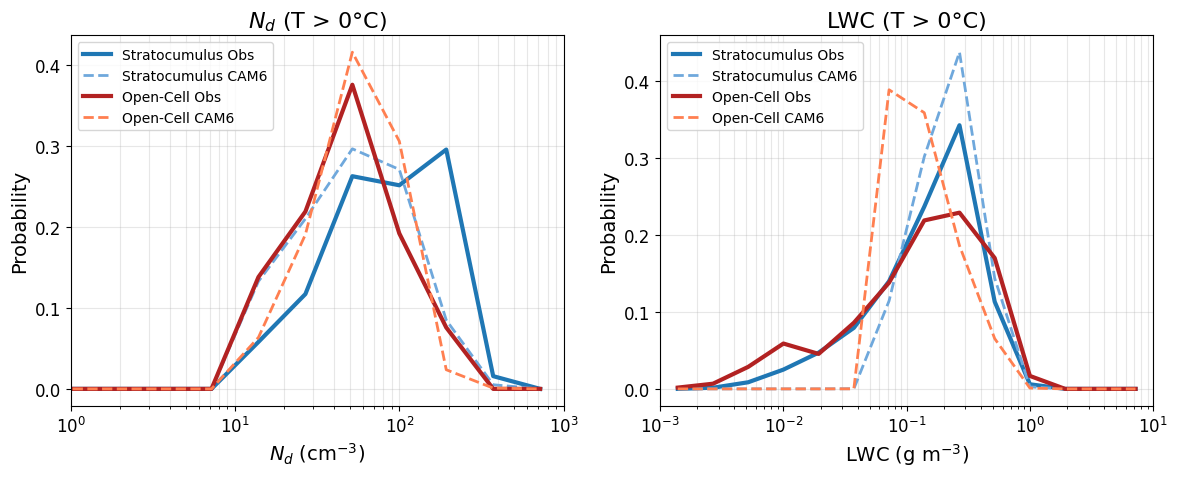

In [16]:
fig, axes, pdfs = plot_obs_cam_nd_lwc_pdfs(
    All_rf_df=All_rf_df,
    ds_cam_comp=ds_cam_comp,
    savepath=None,
)

## 3. Microphysical physical processes figure

In [17]:
fig, axes, out = cdog.plot_sensitivity_vs_sigmaw_2x2_obs_cam(
    df_obs=All_rf_df,
    ds_cam_comp=ds_cam_comp,
    Nd_col="CONCD_RWIO",
    lwc_col="PLWCD_RWIO",
    CCN_col="Nccn_UH_CVIU",
    sigmaw_col="Sigma_w",
    regime_col="cloud_regime",
    Ndriz_col="Ndriz_2DC",
    drizzle_threshold=0.0,
    cam_temp_threshold_K=268.15,
    cam_Nd_var="cam_Nc",
    cam_CCN_var="cam_N_UHSAS",
    cam_sigmaw_var="sigma_w",
    cam_rain_var="cam_Nr",
    cam_rain_threshold=0.0,
    cam_regime_map={"Stratocumulus":"strat", "Open-Cell":"open"},
    n_bins=10,
    min_n=50,
    binning="quantile",
)

AttributeError: module 'cam_diagnostic' has no attribute 'plot_sensitivity_vs_sigmaw_2x2_obs_cam'